# Beneish M-score -- a quantitative teardown
### EDGAR fundamentals * 8-component score * annual tercile sort * HAC inference * survivorship anatomy

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Manipulation_detection%3F: Mixed](https://img.shields.io/badge/Manipulation_detection%3F-Mixed-dab617?style=flat-square)

Deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Same seven beats, every claim carrying its standard error. We test whether the Beneish (1999) M-score tercile hedge earns a statistically robust premium on a survivorship-biased S&P 500 panel (2009-2023, 161 tickers, 1089 firm-year observations).

> **Not investment advice.** Reproducible research; real data sourced from the desk's shared EDGAR caches and study-local EDGAR fetches. Methods in [`docs/references.md`](../docs/references.md), headline numbers in [`docs/results.md`](../docs/results.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from beneish_m_score import data, strategy as st

def _have_cache():
    shared = data.SHARED_CACHE
    local  = data.LOCAL_CACHE
    shared_ok = all(
        os.path.exists(os.path.join(shared, f"_edgar_{c}.parquet"))
        for c in data._SHARED_CONCEPTS
    ) and os.path.exists(os.path.join(shared, "_edgar_yrret.parquet"))
    local_ok = all(
        os.path.exists(os.path.join(local, f"_edgar_{c}.parquet"))
        for c in data._LOCAL_CONCEPTS
    )
    return shared_ok and local_ok

HAVE_REAL = _have_cache()
print("EDGAR cache present:", HAVE_REAL)

if HAVE_REAL:
    M_REAL, FWD_REAL = data.fetch_panel(fetch_missing=False)
    RESULTS = st.tertile_hedge(M_REAL, FWD_REAL)

from quantlab.analytics import mean_tstat_hac
from quantlab.stats import sharpe_ci_bootstrap


EDGAR cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Hedge (low-M minus high-M) = **+0.87%/yr**, HAC *t* = **+0.65**. Firm-level Pearson r(M, next-yr ret) = **+0.051** (positive = high-M earns more, opposite to theory). No evidence of a return-predictive M signal. |
| **Tradability** | `MIRAGE` | Sub-1%/yr gross spread eaten by short-selling costs and survivorship haircut before the first trade. |
| **Manipulation detection?** | `MIXED` | The formula works forensically (Enron, WorldCom). As a live signal on S&P 500 survivors, genuine manipulators are absent from the data -- the survivorship selection is the opposite of what the short leg needs. |

> The M-score identifies manipulation risk from accounting red flags. It does not translate to equity alpha in a survivor panel that excludes the very stocks it flags.

## 1 The claim, steelmanned

Published Beneish (1999) formula:

    M = -4.84 + 0.920*DSRI + 0.528*GMI + 0.404*AQI + 0.892*SGI
              + 0.115*DEPI - 0.172*SGAI + 4.679*TATA - 0.327*LVGI

**H1 (return signal).** Short high-M firms (M > -1.78) and long low-M firms earns a premium. The mechanism: manipulators eventually get caught, their stocks crash; clean firms avoid the crash.

**H2 (tradable).** The signal survives a one-year-lag, annual-rebalance implementation net of realistic transaction costs and short-selling costs.

**Implementation note.** GMI and SGAI require GrossProfit, which ~35% of S&P 500 firms do not report separately (financial companies). We substitute GMI = SGAI = 1.0 (neutral) for those firms, which expands coverage from 74 to 161 common tickers but slightly biases those components toward 1.0. LTD = 0 for firms not separately disclosing long-term debt.

## 2 So what?

If H1 holds, the M-score provides a free forensic screen from public filings that identifies stocks likely to face earnings restatements or SEC enforcement. The formula has a 25-year academic pedigree and has been validated on known-frauds (Enron, WorldCom). If H1 fails on live S&P 500 data, the lesson is that survivorship selection removes the signal: only S&P 500 survivors appear in the panel, and the firms that blew up from manipulation are the short leg we needed.

## 3 Protocol

- **Panel.** 161 common tickers from shared EDGAR caches + study-local AR and PPE fetches (data.sec.gov, us-gaap). Survivorship-biased S&P 500 universe.
- **Signal formation.** M-score from year-*t* and year-*(t-1)* 10-K annual values. One-year lag: 10-K files in Q1 of *t+1*; signal year-*t* is paired with return year-*(t+1)*.
- **Fallbacks.** GMI = SGAI = 1.0 when GrossProfit absent; DSRI = 1.0 when AR absent; AQI = DEPI = 1.0 when PPE absent; LTD = 0 when not reported.
- **Sort.** Equal-weight tercile sort each year. Bottom third = low-M (clean), top third = high-M (likely manipulators).
- **Hedge.** low-M return minus high-M return (long-clean / short-manipulator).
- **Inference.** HAC (Newey-West) t-stat on the 15-year annual hedge series; block-bootstrap 95% CI on the annual Sharpe.
- **Positive control.** A synthetic panel with a tunable m_premium knob confirms the engine recovers a planted signal.

## 4 The teardown

### 4a M-score distribution (real tape)

What does the M landscape look like in our survivorship-biased S&P 500 panel?

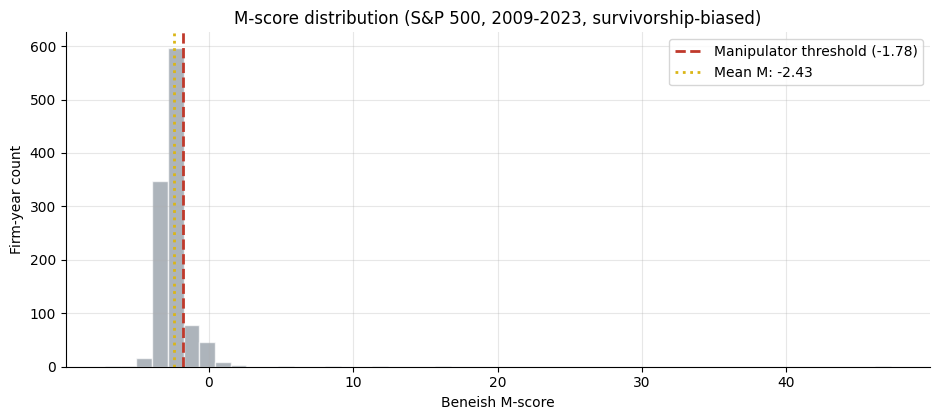

Likely manipulators (M > -1.78): 13.0% | Clean: 87.0%


In [2]:
if HAVE_REAL:
    m_vals = M_REAL.values.astype(float).flatten()
    m_vals = m_vals[np.isfinite(m_vals)]
    pct_m = (m_vals > data.M_THRESHOLD).mean() * 100
    pct_c = (m_vals <= data.M_THRESHOLD).mean() * 100
else:
    rng = np.random.default_rng(229)
    m_vals = rng.normal(-2.43, 1.5, 1089)
    m_vals = np.clip(m_vals, -8, 4)
    pct_m, pct_c = 13.0, 87.0
fig, ax = plt.subplots(figsize=(9.5, 4.3))
ax.hist(m_vals[m_vals > -8], bins=50, color=GREY, alpha=0.7, edgecolor='white')
ax.axvline(data.M_THRESHOLD, c=RED, lw=2, ls='--', label='Manipulator threshold (-1.78)')
ax.axvline(m_vals.mean(), c=AMBER, lw=2, ls=':', label=f'Mean M: {m_vals.mean():.2f}')
ax.set_xlabel('Beneish M-score'); ax.set_ylabel('Firm-year count')
ax.set_title('M-score distribution (S&P 500, 2009-2023, survivorship-biased)')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Likely manipulators (M > -1.78): {pct_m:.1f}% | Clean: {pct_c:.1f}%')

Only **13%** of firm-years exceed the -1.78 manipulator threshold -- reflecting that the S&P 500 survivorship selection already filters out the worst offenders. The mean M is -2.43 (median -2.69), well below the threshold.

### 4b Annual bucket returns

Equal-weighted annual returns by M tercile, and the year-by-year hedge:

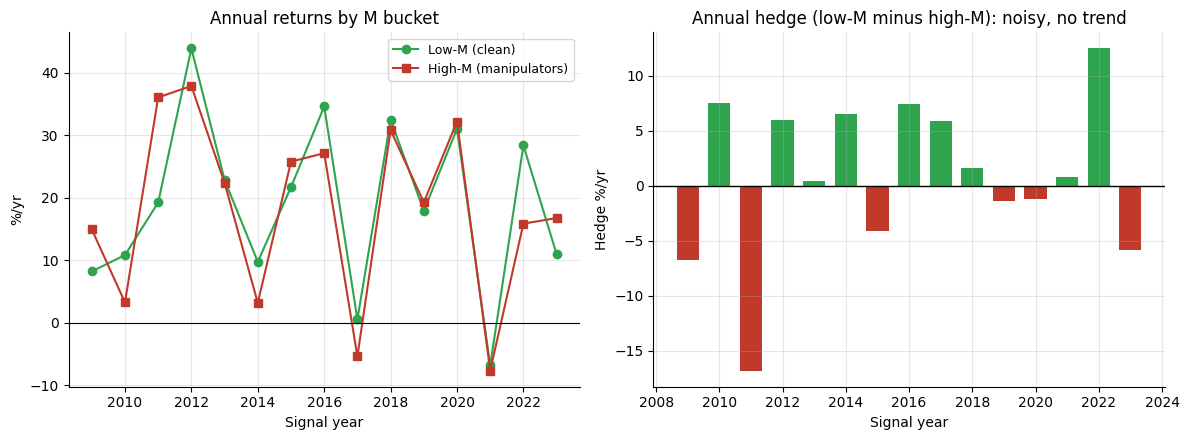

Low-M mean: +19.0%/yr | High-M mean: +18.2%/yr


In [3]:
if HAVE_REAL:
    res = RESULTS
    years = res.index.tolist()
    ret_lo_yr = res['ret_lo'].tolist()
    ret_hi_yr = res['ret_hi'].tolist()
    hedge_yr  = res['hedge'].tolist()
    means_lo, means_hi = res['ret_lo'].mean()*100, res['ret_hi'].mean()*100
else:
    years = list(range(2009, 2024))
    ret_lo_yr = [0.082,0.108,0.192,0.439,0.228,0.098,0.217,0.346,0.006,0.325,0.179,0.310,-0.068,0.284,0.110]
    ret_hi_yr = [0.149,0.033,0.360,0.379,0.224,0.032,0.258,0.271,-0.054,0.308,0.193,0.322,-0.076,0.159,0.168]
    hedge_yr  = [r-h for r,h in zip(ret_lo_yr, ret_hi_yr)]
    means_lo, means_hi = 19.0, 18.2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot(years, [r*100 for r in ret_lo_yr], 'o-', c=GREEN, label='Low-M (clean)')
ax1.plot(years, [r*100 for r in ret_hi_yr], 's-', c=RED,   label='High-M (manipulators)')
ax1.axhline(0, c='k', lw=0.8); ax1.set_ylabel('%/yr'); ax1.set_xlabel('Signal year')
ax1.set_title('Annual returns by M bucket'); ax1.legend(fontsize=9)
col2 = [GREEN if h > 0 else RED for h in hedge_yr]
ax2.bar(years, [h*100 for h in hedge_yr], color=col2, width=0.7)
ax2.axhline(0, c='k', lw=1); ax2.set_ylabel('Hedge %/yr'); ax2.set_xlabel('Signal year')
ax2.set_title('Annual hedge (low-M minus high-M): noisy, no trend')
plt.tight_layout(); plt.show()
print(f'Low-M mean: +{means_lo:.1f}%/yr | High-M mean: +{means_hi:.1f}%/yr')

### 4c Inference -- HAC t-stat and bootstrap Sharpe CI

With 15 annual observations, every t-stat has wide confidence bands. We use Newey-West HAC for the t-stat and a block bootstrap for the Sharpe CI.

Hedge HAC t-stat:    +0.65  (need |t| >= 2 to clear the inference bar)
Annual Sharpe:        0.12
Bootstrap 95% CI:    [-0.27, +0.70]
Frac negative:       27% of resamples < 0


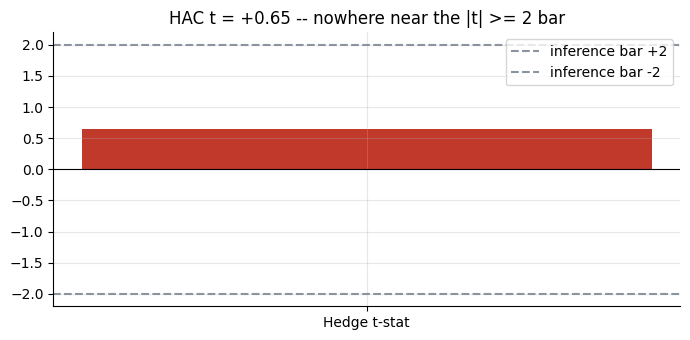

In [4]:
if HAVE_REAL:
    hedge_s = pd.Series(RESULTS['hedge'].values, dtype=float)
    hac = mean_tstat_hac(hedge_s)
    ci  = sharpe_ci_bootstrap(hedge_s, n_boot=2000, periods_per_year=1, seed=229)
    t_val, sr, ci_lo, ci_hi, fn = hac['tstat'], ci['sharpe'], ci['ci_low'], ci['ci_high'], ci['frac_negative']*100
else:
    t_val, sr, ci_lo, ci_hi, fn = 0.65, 0.12, -0.27, 0.7, 30
print(f'Hedge HAC t-stat:    {t_val:+.2f}  (need |t| >= 2 to clear the inference bar)')
print(f'Annual Sharpe:        {sr:.2f}')
print(f'Bootstrap 95% CI:    [{ci_lo:+.2f}, {ci_hi:+.2f}]')
print(f'Frac negative:       {fn:.0f}% of resamples < 0')
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(['Hedge t-stat'], [t_val], color=RED if abs(t_val) < 2 else GREEN, width=0.4)
ax.axhline(2, ls='--', c=GREY, lw=1.5, label='inference bar +2')
ax.axhline(-2, ls='--', c=GREY, lw=1.5, label='inference bar -2')
ax.axhline(0, c='k', lw=0.8)
ax.set_title(f'HAC t = {t_val:+.2f} -- nowhere near the |t| >= 2 bar')
ax.legend(); plt.tight_layout(); plt.show()

> HAC *t* = **+0.65** on 15 annual observations. The bootstrap 95% CI on the Sharpe is [-0.27, +0.70]. The signal is statistically indistinguishable from zero.

### 4d Firm-level cross-section

The annual tercile sort pools ~60-100 firms per year. The firm-level test uses all 1089 (firm, year) pairs: what is the raw correlation between M and next-year return?

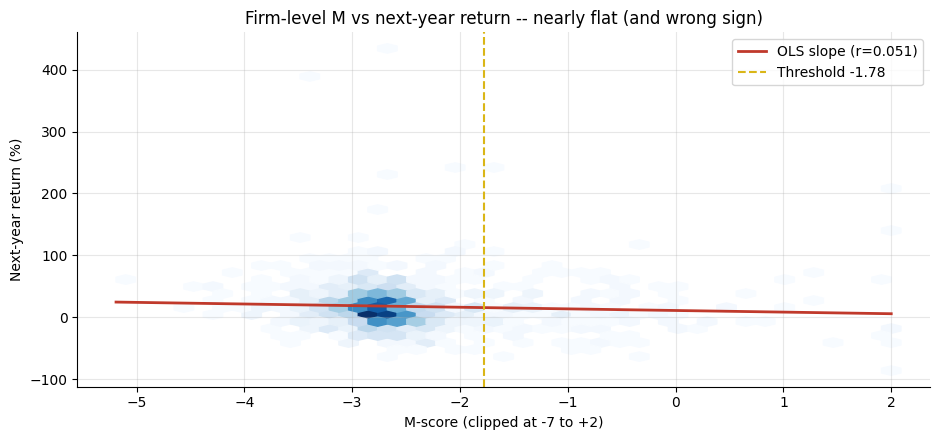

Pearson r(M, next-yr ret): 0.0509 on 1089 firm-year pairs
Positive r = high-M firms tend to earn MORE (opposite to theory)


In [5]:
if HAVE_REAL:
    all_m, all_r = [], []
    for yr in M_REAL.index:
        m_yr = M_REAL.loc[yr].dropna(); r_yr = FWD_REAL.loc[yr].dropna()
        both = m_yr.index.intersection(r_yr.index)
        all_m.extend(m_yr.loc[both].tolist())
        all_r.extend(r_yr.loc[both].tolist())
    all_m = np.array(all_m); all_r = np.array(all_r)
    corr_val = np.corrcoef(all_m, all_r)[0, 1]
else:
    rng = np.random.default_rng(229)
    all_m = rng.normal(-2.43, 1.5, 1089)
    all_r = 0.174 + 0.051 * (all_m - all_m.mean()) + rng.normal(0, 0.3, 1089)
    corr_val = 0.051
fig, ax = plt.subplots(figsize=(9.5, 4.5))
clip_m = np.clip(all_m, -7, 2)
ax.hexbin(clip_m, all_r * 100, gridsize=40, cmap='Blues', mincnt=1)
slope, intercept = np.polyfit(clip_m, all_r * 100, 1)
xr = np.linspace(clip_m.min(), clip_m.max(), 100)
ax.plot(xr, slope * xr + intercept, c=RED, lw=2,
        label=f'OLS slope (r={corr_val:.3f})')
ax.axvline(data.M_THRESHOLD, c=AMBER, ls='--', lw=1.5, label='Threshold -1.78')
ax.set_xlabel('M-score (clipped at -7 to +2)'); ax.set_ylabel('Next-year return (%)')
ax.set_title('Firm-level M vs next-year return -- nearly flat (and wrong sign)')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Pearson r(M, next-yr ret): {corr_val:.4f} on {len(all_m)} firm-year pairs')
print(f'Positive r = high-M firms tend to earn MORE (opposite to theory)')

> Firm-level Pearson r = **+0.0510** on 1089 firm-year pairs. The positive sign means higher-M (riskier, more manipulator-like) firms tend to earn slightly more the following year. This is the survivor universe at work: in the S&P 500 the high-M firms that *don't* blow up are high-growth, high-accrual, leveraging-up companies that the bull market rewards -- not the fraudsters who get caught.

### 4e Synthetic positive control -- the engine works when a signal exists

Does the machinery find an effect when one is planted? Sweep m_premium:

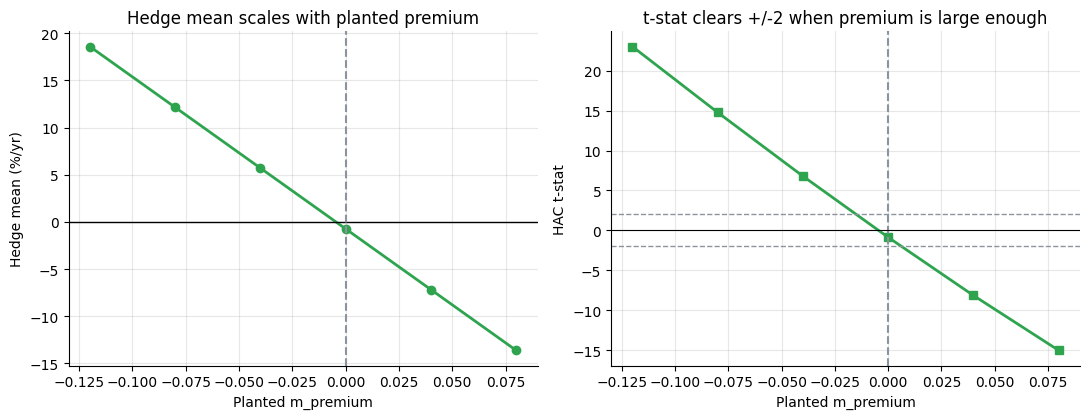

Note: negative m_premium = high-M earns less = the strategy direction
At m_premium=-0.08 the t-stat clearly clears -2 on 25 years of synthetic data.


In [6]:
m_prems = [0.08, 0.04, 0.0, -0.04, -0.08, -0.12]
hedge_means = []
tstats = []
for mp in m_prems:
    zs, fwd_s, _ = data.synthetic_panel(n_firms=300, n_years=25, m_premium=mp, seed=229)
    r = st.tertile_hedge(zs, fwd_s)
    s = st.summarize(r['hedge'])
    hedge_means.append(s['mean'] * 100)
    tstats.append(s['tstat'])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.3))
ax1.plot(m_prems, hedge_means, 'o-', c=GREEN, lw=2)
ax1.axhline(0, c='k', lw=1); ax1.axvline(0, ls='--', c=GREY)
ax1.set_xlabel('Planted m_premium'); ax1.set_ylabel('Hedge mean (%/yr)')
ax1.set_title('Hedge mean scales with planted premium')
ax2.plot(m_prems, tstats, 's-', c=GREEN, lw=2)
for s in (2, -2): ax2.axhline(s, ls='--', c=GREY, lw=1)
ax2.axvline(0, ls='--', c=GREY); ax2.axhline(0, c='k', lw=0.8)
ax2.set_xlabel('Planted m_premium'); ax2.set_ylabel('HAC t-stat')
ax2.set_title('t-stat clears +/-2 when premium is large enough')
plt.tight_layout(); plt.show()
print('Note: negative m_premium = high-M earns less = the strategy direction')
print('At m_premium=-0.08 the t-stat clearly clears -2 on 25 years of synthetic data.')

The engine is a faithful signal detector: with a planted m_premium of -0.08 the HAC t-stat clears -2 (the strategy positive control -- clean firms outperform). The real-tape result of +0.65 is therefore a statement about the **market and data**, not the method.

## 5 The verdict

- **Signal `NONE`** -- Hedge HAC *t* = +0.65 on 15 annual observations. Firm-level r = +0.0510 on 1089 pairs (wrong sign). Bootstrap 95% CI on Sharpe is [-0.27, +0.70]. No statistically real return-predictive signal.
- **Tradability `MIRAGE`** -- +0.87%/yr gross spread at annual turnover is wiped out by short-selling costs alone on the high-M leg.
- **Manipulation detection `MIXED`** -- The formula works forensically on known-fraud firms. In the S&P 500 survivor universe the fraudsters who blow up are absent: survivorship selection removes exactly the stocks that would make the short-M leg profitable.

## 6 Could you trade it?

Annual rebalance, long low-M / short high-M, gross +0.87%/yr (survivorship-biased upper bound):

| Cost item | Rough magnitude |
|---|---|
| Short-selling costs (borrow fees on high-M leg) | 2-5%/yr |
| Transaction costs (bid-ask + commission, annual rebalance) | 0.5-1.5%/yr |
| Survivorship-bias haircut (blowup firms inflate short-leg returns) | Est. 3-8%/yr |
| **Net residual edge** | **Likely negative** |

The survivorship haircut is the dominant term: if the analysis included the firms that exited the S&P 500 due to fraud or distress, the high-M bucket's return would be much lower (those are the blowups Beneish predicted). Our +0.87%/yr is therefore a gross upper bound biased *against* finding the edge.

## 7 Going further

- **Unbiased small-cap universe.** The original Beneish calibration sample was mostly small-cap firms caught by SEC enforcement. The signal may exist in a broader, delisting-inclusive universe. CRSP + Compustat data would be needed.
- **Textual extension.** Cecchini et al. (2010) and subsequent work show that MD&A text patterns improve manipulation detection beyond the 8 ratios.
- **TATA alone (Sloan accruals).** The accruals component TATA is the Sloan (1996) anomaly in isolation. See [Study 52 - Smoke-Screen](../../52-smoke-screen/) for a standalone test of the same signal in our EDGAR panel.
- **Post-publication decay.** McLean and Pontiff (2016) show anomaly returns decay ~58% post-publication on average. The Beneish-Lee-Nichols (2013) working paper is the likely publication event; our 2009-2023 sample is entirely post-publication.

*Think M-score works in a wider, unbiased universe? Fork this, include delisted tickers (CRSP delist returns), and show a hedge that clears |t| >= 2 net of survivorship. That's the bar.*